In [2]:
#Libs
import pandas as pd
import numpy as np

#libs gráficas
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

#Google Cloud Platform (Dados do Censo 2022)
from google.colab import auth
from google.cloud import bigquery
from google.colab import files

#Avisos
import warnings
warnings.filterwarnings('ignore')

## Importação de dados da Gold no S3 e fontes externas (IBGE, Censo) via BigQuery

In [3]:
#Pyarrow para baixar dados de buckets S3 da camada Gold
!pip install s3fs pyarrow pandas

import pandas as pd

# VARIAVEIS
s3_path_comparativo_metas_resultados = "s3://fiap-datalake-tech-public/gold/comparativo_metas_resultados/"
s3_path_evolucao_temporal_estado = "s3://fiap-datalake-tech-public/gold/evolucao_temporal_estado/"
s3_path_indicador_alfabetizacao_municipio = "s3://fiap-datalake-tech-public/gold/indicador_alfabetizacao_municipio/"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 64.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.7.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.7.0 which is incompatible.


In [4]:
#Autenticação GCP para coletar dados do Censo 2022, IPEA e do IBGE
#https://basedosdados.org/dataset/08a1546e-251f-4546-9fe0-b1e6ab2b203d?table=cf9537b5-6198-455f-a8b0-7c762e94d79c
#https://basedosdados.org/dataset/08a1546e-251f-4546-9fe0-b1e6ab2b203d?table=707fd42e-95e0-4856-922f-fcbb55db913a
#https://basedosdados.org/dataset/fcf025ca-8b19-4131-8e2d-5ddb12492347?table=fbbbe77e-d234-4113-8af5-98724a956943
#https://www.ipeadata.gov.br/Default.aspx (Renda per capita média de 2010 (seção social - tema renda - renda geral))


auth.authenticate_user()
print('Autenticado com sucesso!')

Autenticado com sucesso!


In [5]:
df_comparativo_metas_resultados = pd.read_parquet(
    s3_path_comparativo_metas_resultados,
    engine="pyarrow",
    storage_options={"anon": True}  # Para acesso público
)

df_comparativo_metas_resultados.head(n=5)

,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version
0,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
1,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
2,2023,RO,1101450,Parecis,55,56.36,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
3,2023,AM,1300631,Beruri,243,89.71,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
4,2023,AM,1301605,Fonte Boa,380,38.95,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3


In [ ]:
df_evol_estado = pd.read_parquet(
    s3_path_evolucao_temporal_estado,
    engine="pyarrow",
    storage_options={"anon": True}  # Para acesso público
)

df_evol_estado.head(n=5)

,ano,sigla_uf,total_avaliados_estado,total_alfabetizados_estado,taxa_alfabetizacao_estado,_gold_processed_at,_analytics_version
0,2024,AC,10234,5311,51.90,2026-07-14 21:33:08.935038,v3.0_spark_native_s3
1,2025,AC,10589,7158,67.60,2026-07-14 21:33:08.935038,v3.0_spark_native_s3
2,2023,AL,32789,14584,44.48,2026-07-14 21:33:08.935038,v3.0_spark_native_s3
3,2024,AL,31575,15454,48.94,2026-07-14 21:33:08.935038,v3.0_spark_native_s3
4,2025,AL,33161,21273,64.15,2026-07-14 21:33:08.935038,v3.0_spark_native_s3


In [ ]:
df_indic_alfab_municipio = pd.read_parquet(
    s3_path_indicador_alfabetizacao_municipio,
    engine="pyarrow",
    storage_options={"anon": True}  # Para acesso público
)

df_indic_alfab_municipio.head(n=5)

,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,total_alfabetizados,taxa_alfabetizacao_real,_gold_processed_at,_analytics_version
0,2023,RO,1100072,Corumbiara,119,71,59.66,2026-07-14 21:32:46.811332,v3.0_spark_native_s3
1,2023,RO,1100122,Ji-Paraná,1496,1055,70.52,2026-07-14 21:32:46.811332,v3.0_spark_native_s3
2,2023,RO,1101450,Parecis,55,31,56.36,2026-07-14 21:32:46.811332,v3.0_spark_native_s3
3,2023,AM,1300631,Beruri,243,218,89.71,2026-07-14 21:32:46.811332,v3.0_spark_native_s3
4,2023,AM,1301605,Fonte Boa,380,148,38.95,2026-07-14 21:32:46.811332,v3.0_spark_native_s3


In [ ]:
#Baixar csv do Censo 2022 para coletar dados de população por município, raça

# Meu ID do projeto no GCP
project_id = 'gcpproject-500123'
client = bigquery.Client(project=project_id)

# Query
query = """
    SELECT
    dados.id_municipio AS id_municipio,
    diretorio_id_municipio.nome AS id_municipio_nome,
    dados.cor_raca as cor_raca,
    dados.sexo as sexo,
    dados.grupo_idade as grupo_idade,
    dados.alfabetizacao as alfabetizacao,
    dados.populacao as populacao
FROM `basedosdados.br_ibge_censo_2022.alfabetizacao_grupo_idade_sexo_raca` AS dados
LEFT JOIN (SELECT DISTINCT id_municipio,nome  FROM `basedosdados.br_bd_diretorios_brasil.municipio`) AS diretorio_id_municipio
    ON dados.id_municipio = diretorio_id_municipio.id_municipio
"""

# Executa e converte para Pandas DataFrame
df_censo_raca = client.query(query).to_dataframe()

# Exibe as primeiras linhas
df_censo_raca.head()

## Salvar o DataFrame no ambiente do Colab
#df_censo_raca.to_csv('censo_2022_popul_sexo_raca.csv', index=False)

## Fazer o download para sua máquina
#files.download('censo_2022_popul_sexo_raca.csv')



,id_municipio,id_municipio_nome,cor_raca,sexo,grupo_idade,alfabetizacao,populacao
0,1100023,Ariquemes,Indígena,Homens,15 a 19 anos,Não alfabetizadas,<NA>
1,1100262,Rio Crespo,Amarela,Mulheres,15 a 19 anos,Não alfabetizadas,<NA>
2,1101005,Governador Jorge Teixeira,Amarela,Mulheres,15 a 19 anos,Não alfabetizadas,<NA>
3,1101435,Nova União,Amarela,Mulheres,15 a 19 anos,Não alfabetizadas,<NA>
4,1101435,Nova União,Indígena,Mulheres,15 a 19 anos,Não alfabetizadas,<NA>


In [ ]:
df_censo_raca['cor_raca'].unique()

array(['Indígena', 'Amarela', 'Preta', 'Branca', 'Parda'], dtype=object)

In [ ]:
#Baixar csv do Censo 2022 para coletar dados de população por município, area, número de habitantes

# Meu ID do projeto no GCP
project_id = 'gcpproject-500123'
client = bigquery.Client(project=project_id)

# Query
query = """
    SELECT
    dados.id_municipio AS id_municipio,
    diretorio_id_municipio.nome AS id_municipio_nome,
    dados.sigla_uf as sigla_uf,
    dados.populacao as populacao,
    dados.area as area,
    dados.populacao_indigena as populacao_indigena,
    dados.populacao_quilombola as populacao_quilombola
FROM `basedosdados.br_ibge_censo_2022.municipio` AS dados
LEFT JOIN (SELECT DISTINCT id_municipio,nome  FROM `basedosdados.br_bd_diretorios_brasil.municipio`) AS diretorio_id_municipio
    ON dados.id_municipio = diretorio_id_municipio.id_municipio
"""

# Executa e converte para Pandas DataFrame
df_censo_populacao = client.query(query).to_dataframe()

# Exibe as primeiras linhas
df_censo_populacao.head()

## Salvar o DataFrame no ambiente do Colab
#df.to_csv('censo_2022_area_estado_municipio.csv', index=False)

## Fazer o download para sua máquina
#files.download('censo_2022_area_estado_municipio.csv')


,id_municipio,id_municipio_nome,sigla_uf,populacao,area,populacao_indigena,populacao_quilombola
0,1400704,Uiramutã,RR,13695,8114,13264,0
1,1200435,Santa Rosa do Purus,AC,6717,6156,4297,0
2,1400407,Normandia,RR,13893,6960,12397,0
3,1200328,Jordão,AC,9201,5357,4109,0
4,1303908,São Paulo de Olivença,AM,32931,19659,26603,0


In [ ]:
#Baixar csv com dados do IBGE (PIB) por município

# Meu ID do projeto no GCP
project_id = 'gcpproject-500123'
client = bigquery.Client(project=project_id)

# Query
query = """
    SELECT
    dados.id_municipio AS id_municipio,
    diretorio_id_municipio.nome AS id_municipio_nome,
    dados.ano as ano,
    dados.pib as pib
FROM `basedosdados.br_ibge_pib.municipio` AS dados
LEFT JOIN (SELECT DISTINCT id_municipio,nome  FROM `basedosdados.br_bd_diretorios_brasil.municipio`) AS diretorio_id_municipio
    ON dados.id_municipio = diretorio_id_municipio.id_municipio
"""

# Executa e converte para Pandas DataFrame
df_ibge_pib_municipio = client.query(query).to_dataframe()

# Exibe as primeiras linhas
df_ibge_pib_municipio.head()

## Salvar o DataFrame no ambiente do Colab
#df.to_csv('ibge_pib_municipio.csv', index=False)

## Fazer o download para sua máquina
#files.download('ibge_pib_municipio.csv')

,id_municipio,id_municipio_nome,ano,pib
0,1100403,Alto Paraíso,2002,45060000
1,1101005,Governador Jorge Teixeira,2002,43979000
2,1200336,Mâncio Lima,2002,31111000
3,1200385,Plácido de Castro,2002,54088000
4,1301654,Guajará,2002,26050000


In [ ]:
#Acessar CSV do Atlas DH (Censo 2010) - IPEA

df_renda_media = pd.read_csv('ipeadata[25-08-2026-10-18]-renda_percapitamedia_2010.csv')

df_renda_media.head()

,Sigla,Código,Município,Renda per capita média,Ano
0,AC,1200013,Acrelândia,"303,76",2010.0
1,AC,1200054,Assis Brasil,"291,33",2010.0
2,AC,1200104,Brasiléia,"376,07",2010.0
3,AC,1200138,Bujari,"340,95",2010.0
4,AC,1200179,Capixaba,"336,17",2010.0


In [ ]:
print(f"Valores únicos: {df_renda_media['Ano'].unique()}")
print(f"Quantidade de registros nulos na coluna Ano: {df_renda_media['Ano'].isna().sum()}")
print(f"Quantidade de registros 2010: {df_renda_media['Ano'].value_counts()}")

Valores únicos: [2010.   nan]
Quantidade de registros nulos na coluna Ano: 4978
Quantidade de registros 2010: Ano
2010.0    619
Name: count, dtype: int64


## ETL dos dados adicionais para Gold atual
Nessa seção iremos simular a inclusão das seguintes informações na camada gold do S3 da AWS:
- Área do municipio
- População total do municipio
- População por tipo (indigenas e quilombolas)
- Sexo
- Raça
- PIB do municipio
- Renda média mensal per capita

 Com essas inclusões, faremos o EDA e identificaremos quais transformações das camadas raw, silver e gold poderão, possivelmente, contribuir para a performance dos modelos preditivos, evitando assim, inclusão de dados que atrapalharão a etapa de feature selection com uma alta dimensionalidade.

In [126]:
## Criando dataframe de dados demográficos

df_gold_dados_demograficos = df_censo_populacao.copy()


# Criar total por Etnia
df_gold_dados_demograficos['populacao_indigena_%'] = (
    df_gold_dados_demograficos['populacao_indigena'] / df_gold_dados_demograficos['populacao']
) * 100

df_gold_dados_demograficos['populacao_quilombola_%'] = (
    df_gold_dados_demograficos['populacao_quilombola'] / df_gold_dados_demograficos['populacao']
) * 100
df_gold_dados_demograficos = df_gold_dados_demograficos.drop(columns=['populacao_indigena', 'populacao_quilombola'])

# #Renomeia coluna de população do dataframe de raça para não conflitar com dataframe de população
df_censo_raca = df_censo_raca.rename(columns={
    'populacao': 'populacao_raca'
})

# Criar total por Sexo
df_sexo = df_censo_raca.pivot_table(
    index='id_municipio',
    columns='sexo',
    values='populacao_raca',
    aggfunc='sum',
    fill_value=0
)


df_sexo_pct = df_sexo.div(df_sexo.sum(axis=1), axis=0) * 100

df_sexo_pct = df_sexo_pct.rename(columns={
    'Homens': 'populacao_genero_homens_%',
    'Mulheres': 'populacao_genero_mulheres_%'
}).reset_index()



# Criar total por Raça
df_raca = df_censo_raca.pivot_table(
    index='id_municipio',
    columns='cor_raca',
    values='populacao_raca',
    aggfunc='sum',
    fill_value=0
)

df_raca_pct = df_raca.div(df_raca.sum(axis=1), axis=0) * 100

df_raca_pct.columns = [f"populacao_{c.lower()}_%" for c in df_raca_pct.columns]
df_raca_pct = df_raca_pct.reset_index()

#Dropar colunas não utilizadas
df_raca_pct = df_raca_pct.drop(columns=['populacao_indígena_%'])

# Unir tudo no DataFrame principal

df_gold_dados_demograficos = df_gold_dados_demograficos.astype({
    'id_municipio': 'int64',
  })
df_sexo_pct = df_sexo_pct.astype({
    'id_municipio': 'int64',
  })

df_raca_pct = df_raca_pct.astype({
    'id_municipio': 'int64',
  })

df_gold_dados_demograficos = df_gold_dados_demograficos.merge(df_sexo_pct, on='id_municipio', how='left')
df_gold_dados_demograficos = df_gold_dados_demograficos.merge(df_raca_pct, on='id_municipio', how='left')


#Renomear etnias e raça
df_gold_dados_demograficos = df_gold_dados_demograficos.rename(columns={
    'populacao_branca_%': 'populacao_raca_branca_%',
    'populacao_preta_%': 'populacao_raca_preta_%',
    'populacao_amarela_%': 'populacao_raca_amarela_%',
    'populacao_parda_%': 'populacao_raca_parda_%',
    'populacao_indigena_%': 'populacao_etnia_indigena_%',
    'populacao_quilombola_%': 'populacao_etnia_quilombola_%',
})

#Criar coluna de densidade demográfica
df_gold_dados_demograficos['densidade_demografica'] = df_gold_dados_demograficos['populacao'] / df_gold_dados_demograficos['area']


df_gold_dados_demograficos.head()

,id_municipio,id_municipio_nome,sigla_uf,populacao,area,populacao_etnia_indigena_%,populacao_etnia_quilombola_%,populacao_genero_homens_%,populacao_genero_mulheres_%,populacao_raca_amarela_%,populacao_raca_branca_%,populacao_raca_parda_%,populacao_raca_preta_%,densidade_demografica
0,1400704,Uiramutã,RR,13695,8114,96.852866,0.0,52.408257,47.591743,0.02867,1.462156,5.18922,0.55906,1.687824
1,1200435,Santa Rosa do Purus,AC,6717,6156,63.972011,0.0,51.859612,48.140388,0.026192,8.852803,33.682556,1.702462,1.091131
2,1400407,Normandia,RR,13893,6960,89.231987,0.0,52.053907,47.946093,0.025917,3.511727,22.612414,1.29584,1.996121
3,1200328,Jordão,AC,9201,5357,44.658189,0.0,52.549311,47.450689,0.148865,11.648679,46.818013,7.480461,1.717566
4,1303908,São Paulo de Olivença,AM,32931,19659,80.784064,0.0,52.008203,47.991797,0.025009,2.675937,38.498474,1.190417,1.675111


In [ ]:
## Criando dataframe de dados socioeconômicos

#Dados do IBGE (PIB)
df_gold_dados_socioeconomicos = df_ibge_pib_municipio.loc[
    df_ibge_pib_municipio.groupby('id_municipio')['ano'].idxmax()
].reset_index(drop=True)

#Dados de renda média mensal per capita (IPEA 2010)
df_renda_media = df_renda_media.rename(columns={
    'Município': 'id_municipio_nome',
    'Código': 'id_municipio',
    'Sigla': "sigla_uf",
    'Renda per capita média': 'renda_media_per_capita',
    'Ano': 'ano_renda'
})

df_gold_dados_socioeconomicos = df_gold_dados_socioeconomicos.rename(columns={
    'ano': 'ano_pib'
})

df_gold_dados_socioeconomicos['id_municipio'] = df_gold_dados_socioeconomicos['id_municipio'].astype('int64')
df_renda_media['id_municipio'] = df_renda_media['id_municipio'].astype('int64')

df_gold_dados_socioeconomicos = df_gold_dados_socioeconomicos.merge(df_renda_media[['id_municipio','sigla_uf','renda_media_per_capita','ano_renda']], on='id_municipio', how='left')

df_gold_dados_socioeconomicos.head()

,id_municipio,id_municipio_nome,ano_pib,pib,sigla_uf,renda_media_per_capita,ano_renda
0,1100015,Alta Floresta D'Oeste,2023,1046343000,RO,"476,99",NaN
1,1100023,Ariquemes,2023,4383815000,RO,"689,95",NaN
2,1100031,Cabixi,2023,300832000,RO,"457,17",NaN
3,1100049,Cacoal,2023,3848468000,RO,"738,06",NaN
4,1100056,Cerejeiras,2023,1006389000,RO,"577,18",NaN


In [131]:
##Calculando a média de PIB e Renda por municipio do dataframe df_gold_dados_socioeconomicos

# Garante que a coluna de ano seja numérica
df_gold_dados_socioeconomicos['ano_pib'] = pd.to_numeric(df_gold_dados_socioeconomicos['ano_pib'])


# Seleciona apenas a linha do ano mais recente para cada id_municipio
df_pib_mais_recente = df_gold_dados_socioeconomicos.loc[
    df_gold_dados_socioeconomicos.groupby('id_municipio')['ano_pib'].idxmax()
].copy()


# Renomeia colunas para clareza
df_pib_mais_recente = df_pib_mais_recente.rename(columns={
    'pib': 'pib_R$'
})



# Garante que a coluna de ano seja numérica
df_gold_dados_socioeconomicos['ano_pib'] = pd.to_numeric(df_gold_dados_socioeconomicos['ano_pib'])


# Seleciona apenas a linha do ano mais recente para cada id_municipio
df_renda_mais_recente = df_gold_dados_socioeconomicos.loc[
    df_gold_dados_socioeconomicos.groupby('id_municipio')['ano_pib'].idxmax()
].copy()

# Padroniza o tipo da chave em ambos
df_pib_mais_recente = df_pib_mais_recente.astype({
    'id_municipio': 'int64'
  })

df_renda_mais_recente =  df_renda_mais_recente.astype({
    'id_municipio': 'int64'
  })

# Realiza o merge apenas com o ano mais recente de cada indicador
df_dados_socioeconomicos_agrupados = df_pib_mais_recente[[
    'id_municipio', 'pib_R$', 'ano_pib'
]].merge(
    df_renda_mais_recente[['id_municipio', 'id_municipio_nome', 'sigla_uf', 'renda_media_per_capita']],
    on='id_municipio',
    how='inner'
)

# Renomeia colunas
df_dados_socioeconomicos_agrupados = df_pib_mais_recente.rename(columns={
    'id_municipio_nome': 'municipio_nome',
    '	renda_media_per_capita' : 'renda_media_per_capita_R$'
})

#Dropar colunas
df_dados_socioeconomicos_agrupados = df_dados_socioeconomicos_agrupados.drop(columns=['ano_pib'])

#Merge de dados socioeconomicos agrupados com tabela de população para chegar no PIB per capita
df_dados_socioeconomicos_agrupados = df_dados_socioeconomicos_agrupados.merge(
    df_gold_dados_demograficos[['id_municipio','populacao']],
    on='id_municipio',
    how='left'
)

df_dados_socioeconomicos_agrupados['pib_per_capita_R$'] = df_dados_socioeconomicos_agrupados['pib_R$'] / df_dados_socioeconomicos_agrupados['populacao']
df_dados_socioeconomicos_agrupados = df_dados_socioeconomicos_agrupados.drop(columns=['populacao','ano_renda'])

#Renomear renda média per capita
df_dados_socioeconomicos_agrupados = df_dados_socioeconomicos_agrupados.rename(columns={
    'renda_media_per_capita': 'renda_media_per_capita_R$'
})


# Reordena as colunas para facilitar a visualização
df_dados_socioeconomicos_agrupados = df_dados_socioeconomicos_agrupados[[
    'id_municipio', 'municipio_nome','sigla_uf','pib_R$','pib_per_capita_R$','renda_media_per_capita_R$'
]]

df_dados_socioeconomicos_agrupados.head()



,id_municipio,municipio_nome,sigla_uf,pib_R$,pib_per_capita_R$,renda_media_per_capita_R$
0,1100015,Alta Floresta D'Oeste,RO,1046343000,48803.311567,"476,99"
1,1100023,Ariquemes,RO,4383815000,45592.551377,"689,95"
2,1100031,Cabixi,RO,300832000,56219.772005,"457,17"
3,1100049,Cacoal,RO,3848468000,44494.04583,"738,06"
4,1100056,Cerejeiras,RO,1006389000,63703.570072,"577,18"


In [ ]:
print(f"Quantidade de registros nulos na coluna PIB: {df_dados_socioeconomicos_agrupados['pib_R$'].isna().sum()}")
print(f"Quantidade de registros nulos na coluna Renda: {df_dados_socioeconomicos_agrupados['renda_media_per_capita_R$'].isna().sum()}")

Quantidade de registros nulos na coluna PIB: 0
Quantidade de registros nulos na coluna Renda: 6


In [132]:
##Criando dataset que faz merge entre dados socioeconomicos e densidade populacional por municipio

# Garante que id_municipio seja string em ambos os DataFrames
df_dados_socioeconomicos_agrupados['id_municipio'] = df_dados_socioeconomicos_agrupados['id_municipio'].astype(str)
df_gold_dados_demograficos['id_municipio'] = df_gold_dados_demograficos['id_municipio'].astype(str)

df_dados_socioeconomicos_agrupados = df_dados_socioeconomicos_agrupados.astype({
    'id_municipio': 'int64'
  })

df_gold_dados_demograficos =  df_gold_dados_demograficos.astype({
    'id_municipio': 'int64'
  })

# Faz a junção trazendo a coluna densidade_populacional
df_pib_renda_densi_agrupado = df_dados_socioeconomicos_agrupados.merge(
    df_gold_dados_demograficos[['id_municipio', 'densidade_demografica']],
    on='id_municipio',
    how='left'
)

df_pib_renda_densi_agrupado.head()

,id_municipio,municipio_nome,sigla_uf,pib_R$,pib_per_capita_R$,renda_media_per_capita_R$,densidade_demografica
0,1100015,Alta Floresta D'Oeste,RO,1046343000,48803.311567,"476,99",3.033819
1,1100023,Ariquemes,RO,4383815000,45592.551377,"689,95",21.719449
2,1100031,Cabixi,RO,300832000,56219.772005,"457,17",4.072298
3,1100049,Cacoal,RO,3848468000,44494.04583,"738,06",22.803586
4,1100056,Cerejeiras,RO,1006389000,63703.570072,"577,18",5.676608


In [133]:
##Criando dataset que faz merge entre dados socioeconomicos, densidade populacional e taxa de alfabetização por municipio

# Garante que id_municipio seja string em ambos os DataFrames
df_pib_renda_densi_agrupado = df_pib_renda_densi_agrupado.astype({
    'id_municipio': 'int64'
})

df_indic_alfab_municipio = df_indic_alfab_municipio.astype({
    'id_municipio': 'int64'
})

# Faz a junção trazendo a coluna taxa de alfabetização
df_pib_renda_densi__alf_agrupado = df_pib_renda_densi_agrupado.merge(
    df_indic_alfab_municipio[['id_municipio', 'taxa_alfabetizacao_real']],
    on='id_municipio',
    how='left'
)

df_pib_renda_densi__alf_agrupado.head()

,id_municipio,municipio_nome,sigla_uf,pib_R$,pib_per_capita_R$,renda_media_per_capita_R$,densidade_demografica,taxa_alfabetizacao_real
0,1100015,Alta Floresta D'Oeste,RO,1046343000,48803.311567,"476,99",3.033819,68.00
1,1100015,Alta Floresta D'Oeste,RO,1046343000,48803.311567,"476,99",3.033819,78.15
2,1100015,Alta Floresta D'Oeste,RO,1046343000,48803.311567,"476,99",3.033819,67.40
3,1100023,Ariquemes,RO,4383815000,45592.551377,"689,95",21.719449,79.70
4,1100023,Ariquemes,RO,4383815000,45592.551377,"689,95",21.719449,62.52


In [134]:
##Criando dataset que faz merge entre taxa de alfabetização e dados demográficos do municipio

# Garante que id_municipio seja string em ambos os DataFrames
df_indic_alfab_municipio = df_indic_alfab_municipio.astype({
    'id_municipio': 'int64'
})

df_gold_dados_demograficos = df_gold_dados_demograficos.astype({
    'id_municipio': 'int64'
})

# Faz a junção trazendo a coluna taxa de alfabetização
df_t_alf_demograficos = df_indic_alfab_municipio.merge(
    df_gold_dados_demograficos[['id_municipio', 'populacao_genero_homens_%','populacao_genero_mulheres_%','populacao_etnia_indigena_%',	'populacao_etnia_quilombola_%','populacao_raca_amarela_%','populacao_raca_branca_%','populacao_raca_parda_%','populacao_raca_preta_%']],
    on='id_municipio',
    how='left'
)

#Dropar colunas de auditoria da gold
df_t_alf_demograficos = df_t_alf_demograficos.drop(columns=['_gold_processed_at','_analytics_version'])

df_t_alf_demograficos.head()

,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,total_alfabetizados,taxa_alfabetizacao_real,populacao_genero_homens_%,populacao_genero_mulheres_%,populacao_etnia_indigena_%,populacao_etnia_quilombola_%,populacao_raca_amarela_%,populacao_raca_branca_%,populacao_raca_parda_%,populacao_raca_preta_%
0,2023,RO,1100072,Corumbiara,119,71,59.66,52.070808,47.929192,0.0,0.159936,0.1169,29.475618,60.938544,9.185037
1,2023,RO,1100122,Ji-Paraná,1496,1055,70.52,48.596227,51.403773,1.266242,0.0,0.299895,32.574897,56.292157,9.773697
2,2023,RO,1101450,Parecis,55,31,56.36,52.827843,47.172157,1.912702,0.0,0.217526,30.298322,57.178372,10.75202
3,2023,AM,1300631,Beruri,243,218,89.71,52.768218,47.231782,13.187557,0.0,0.029927,11.162652,76.058656,4.646117
4,2023,AM,1301605,Fonte Boa,380,148,38.95,52.147416,47.852584,30.059848,0.0,0.017248,10.584718,71.666762,5.617202


Tamanho das bases de dados



In [ ]:
print(f'Tamanho do dataset: Comparativo Metas e Resultados  (Linhas, Colunas): {df_comparativo_metas_resultados.shape}')
print(f'Tamanho do dataset: Evolução Temporal por Estado  (Linhas, Colunas): {df_evol_estado.shape}')
print(f'Tamanho do dataset: Indicador de Alfabetização por Município  (Linhas, Colunas): {df_indic_alfab_municipio.shape}')
print(f'Tamanho do dataset: Dados demográficos  (Linhas, Colunas): {df_gold_dados_demograficos.shape}')
print(f'Tamanho do dataset: Dados socioeconômicos  (Linhas, Colunas): {df_gold_dados_socioeconomicos.shape}')

Tamanho do dataset: Comparativo Metas e Resultados  (Linhas, Colunas): (15944, 11)
Tamanho do dataset: Evolução Temporal por Estado  (Linhas, Colunas): (76, 7)
Tamanho do dataset: Indicador de Alfabetização por Município  (Linhas, Colunas): (15944, 9)
Tamanho do dataset: Dados demográficos  (Linhas, Colunas): (5570, 14)
Tamanho do dataset: Dados socioeconômicos  (Linhas, Colunas): (5570, 7)


In [ ]:
df_comparativo_metas_resultados.info()
df_evol_estado.info()
df_indic_alfab_municipio.info()
df_gold_dados_demograficos.info()
df_gold_dados_socioeconomicos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15944 entries, 0 to 15943
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ano                      15944 non-null  int32         
 1   sigla_uf                 15944 non-null  object        
 2   id_municipio             15944 non-null  int32         
 3   nome_municipio           15944 non-null  object        
 4   total_avaliados          15944 non-null  int64         
 5   taxa_alfabetizacao_real  15944 non-null  float64       
 6   meta_ano                 10577 non-null  float64       
 7   desvio_meta              10577 non-null  float64       
 8   status_meta              15944 non-null  object        
 9   _gold_processed_at       15944 non-null  datetime64[ns]
 10  _analytics_version       15944 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(4)
memory usage: 1.2+ MB
<class 

In [ ]:
print(f'Quantidade de dados nulos: Comparativo Metas e Resultados: {df_comparativo_metas_resultados.isnull().sum().sum()}')
print(f'Quantidade de dados nulos: Evolução Temporal por Estado: {df_evol_estado.isnull().sum().sum()}')
print(f'Quantidade de dados nulos: Indicador de Alfabetização por Município: {df_indic_alfab_municipio.isnull().sum().sum()}')
print(f'Quantidade de dados nulos: Dados demográficos: {df_gold_dados_demograficos.isnull().sum().sum()}')
print(f'Quantidade de dados nulos: Dados socioeconômicos: {df_gold_dados_socioeconomicos.isnull().sum().sum()}')

Quantidade de dados nulos: Comparativo Metas e Resultados: 10734
Quantidade de dados nulos: Evolução Temporal por Estado: 0
Quantidade de dados nulos: Indicador de Alfabetização por Município: 0
Quantidade de dados nulos: Dados demográficos: 0
Quantidade de dados nulos: Dados socioeconômicos: 4957


In [ ]:
#Top 10 - Estados com médias maiores
df_evol_estado_top10 = df_evol_estado.groupby(['sigla_uf'])[['taxa_alfabetizacao_estado']].mean().round(2).reset_index()

df_evol_estado_top10.sort_values(by='taxa_alfabetizacao_estado', ascending=False).head(10)

,sigla_uf,taxa_alfabetizacao_estado
5,CE,84.56
17,PR,74.82
8,GO,72.94
7,ES,72.68
10,MG,69.26
20,RO,68.08
12,MT,63.91
16,PI,63.42
23,SC,63.40
6,DF,62.28


In [ ]:
#Top 10 - Municipios com médias maiores
df_evol_municipios_top10 = df_comparativo_metas_resultados.groupby(
    ['nome_municipio', 'ano', 'sigla_uf']
)[['taxa_alfabetizacao_real']].mean().round(2).reset_index()

#Filtra apenas os municípios com média igual a 100
df_100_porcento = df_evol_municipios_top10[
    df_evol_municipios_top10['taxa_alfabetizacao_real'] == 100
]

print(f'Quantidade de municipios que atingiram 100%: {df_100_porcento['nome_municipio'].nunique()}')



Quantidade de municipios que atingiram 100%: 186


Na verdade, seria top186 municipios

In [ ]:
df_evol_estado_top10 = df_evol_estado_top10.sort_values(by="taxa_alfabetizacao_estado", ascending=False)

fig = px.bar(df_evol_estado_top10, x='sigla_uf', y='taxa_alfabetizacao_estado', text='taxa_alfabetizacao_estado')

fig.update_layout(title='Gráfico de Barras',
                  xaxis_title='UF',
                  yaxis_title='taxa_alfabetizacao_estado')
fig.show()

In [ ]:
df_medias_estado_status_meta = (
    df_comparativo_metas_resultados
    .groupby(['sigla_uf', 'ano', 'status_meta'])[['taxa_alfabetizacao_real']]
    .mean()
    .round(2)
    .reset_index()
)

# 1. Cria o gráfico com facetas por ano
fig = px.bar(
    df_medias_estado_status_meta,
    x='sigla_uf',
    y='taxa_alfabetizacao_real',
    text='taxa_alfabetizacao_real',
    color='status_meta',
    facet_col='ano',  # Diferencia por ano em painéis
    color_discrete_sequence=['orange', 'red', 'green']
)

# 2. Configura a ordenação: DO MAIOR PARA O MENOR no eixo X
# 'total descending' ordena a UF pela soma das taxas (se houver empilhamento)
# ou pelo valor único da barra (se não houver).
fig.update_layout(
    xaxis={'categoryorder': 'total descending'},

    # Adicionalmente, melhora o layout:
    title='Taxa de Alfabetização por UF (Ordenado Descendente) e Ano',
    xaxis_title='UF',
    yaxis_title='Taxa de Alfabetização Real'
)

# 3. Ajusta o texto para ficar fora das barras e formatação
fig.update_traces(textposition='outside')

fig.show()

*   RR não tem valores de municipio em 2023 e 2024, e em 2025 alguns municipiios entraram nos dados mas sem meta definida.
*   DF não tem meta definida em 2024 e 2025 (em 2023 não se apresenta)



**Existe correlação entre PIB e Renda?**

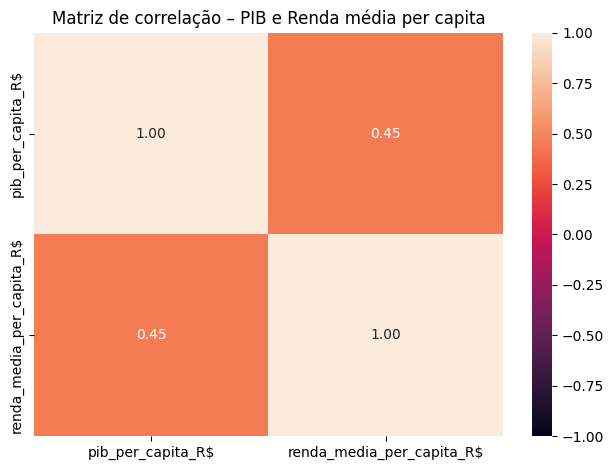

In [ ]:
cols_corr = [c for c in ["pib_per_capita_R$","renda_media_per_capita_R$"] if c in df_dados_socioeconomicos_agrupados.columns]

# 1. Trata e converte as colunas para float
for col in cols_corr:
    # Se a coluna estiver como texto/object, substitui vírgula por ponto e converte para float
    if df_dados_socioeconomicos_agrupados[col].dtype == 'object':
        df_dados_socioeconomicos_agrupados[col] = (
            df_dados_socioeconomicos_agrupados[col]
            .astype(str)
            .str.replace(',', '.')
        )
    df_dados_socioeconomicos_agrupados[col] = pd.to_numeric(
        df_dados_socioeconomicos_agrupados[col],
        errors='coerce'  # Transforma textos inválidos em NaN para evitar erros
    )

# 2. Calcula a correlação
corr = df_dados_socioeconomicos_agrupados[cols_corr].corr()

# 3. Plota o gráfico
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – PIB e Renda média per capita")
plt.tight_layout()
plt.show()

Exislllção entre PIB e Renda média per capita por municipio.

**Existe correlação entre Densidade Populacional, PIB e Renda?**



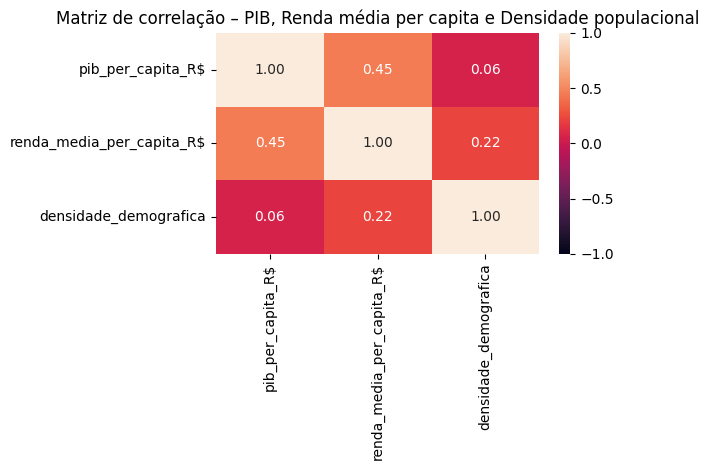

In [143]:
cols_corr = [c for c in ["pib_per_capita_R$", "renda_media_per_capita_R$","densidade_demografica"] if c in df_pib_renda_densi_agrupado.columns]

# 1. Trata e converte as colunas para float
for col in cols_corr:
    # Se a coluna estiver como texto/object, substitui vírgula por ponto e converte para float
    if df_pib_renda_densi_agrupado[col].dtype == 'object':
        df_pib_renda_densi_agrupado[col] = (
            df_pib_renda_densi_agrupado[col]
            .astype(str)
            .str.replace(',', '.')
        )
    df_pib_renda_densi_agrupado[col] = pd.to_numeric(
        df_pib_renda_densi_agrupado[col],
        errors='coerce'  # Transforma textos inválidos em NaN para evitar erros
    )

# 2. Calcula a correlação
corr = df_pib_renda_densi_agrupado[cols_corr].corr()

# 3. Plota o gráfico
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – PIB, Renda média per capita e Densidade populacional")
plt.tight_layout()
plt.show()



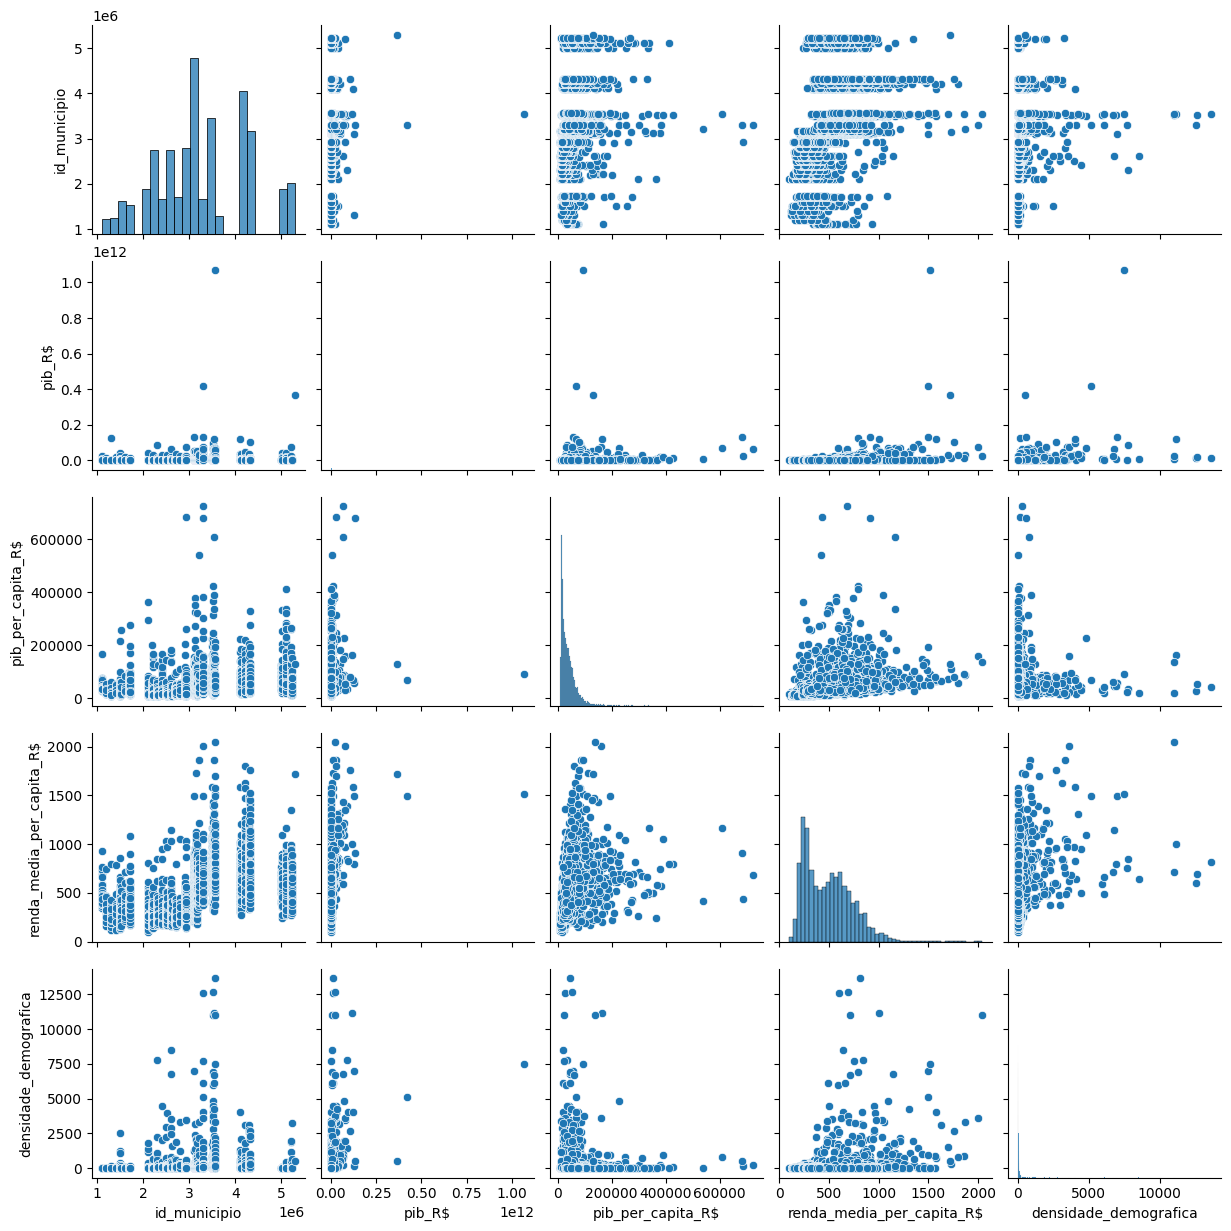

In [142]:
sns.pairplot(df_pib_renda_densi_agrupado)

<Axes: xlabel='pib_per_capita_R$', ylabel='renda_media_per_capita_R$'>

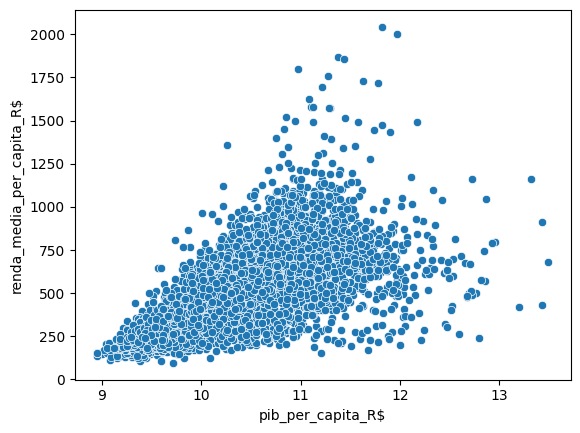

In [144]:
sns.scatterplot(x=np.log(df_pib_renda_densi_agrupado['pib_per_capita_R$']), y=df_pib_renda_densi_agrupado['renda_media_per_capita_R$'])

Existe uma correlação positiva média entre pib per capita e renda média per capita

**Existe correlação entre Densidade Populacional, PIB, Renda e Taxa de Alfabetização?**

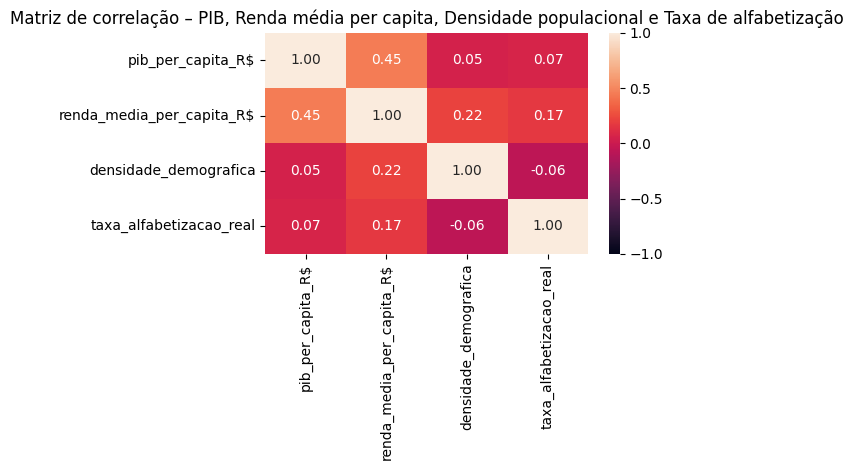

In [139]:
cols_corr = [c for c in ["pib_per_capita_R$", "renda_media_per_capita_R$","densidade_demografica","taxa_alfabetizacao_real"] if c in df_pib_renda_densi__alf_agrupado.columns]

# 1. Trata e converte as colunas para float
for col in cols_corr:
    # Se a coluna estiver como texto/object, substitui vírgula por ponto e converte para float
    if df_pib_renda_densi__alf_agrupado[col].dtype == 'object':
        df_pib_renda_densi__alf_agrupado[col] = (
            df_pib_renda_densi__alf_agrupado[col]
            .astype(str)
            .str.replace(',', '.')
        )
    df_pib_renda_densi__alf_agrupado[col] = pd.to_numeric(
        df_pib_renda_densi__alf_agrupado[col],
        errors='coerce'  # Transforma textos inválidos em NaN para evitar erros
    )

# 2. Calcula a correlação
corr = df_pib_renda_densi__alf_agrupado[cols_corr].corr()

# 3. Plota o gráfico
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – PIB, Renda média per capita, Densidade populacional e Taxa de alfabetização")
plt.tight_layout()
plt.show()

A inclusão da taxa de alfabetização tem pouca influência nos outros indicadores.

**Existe correlação entre Taxa de Alfabetização e Dados Demográficos?**

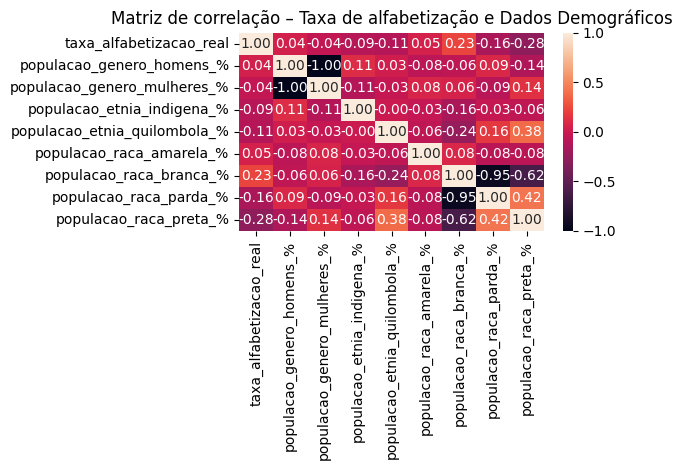

In [138]:
cols_corr = [c for c in ["taxa_alfabetizacao_real",'populacao_genero_homens_%','populacao_genero_mulheres_%','populacao_etnia_indigena_%',	'populacao_etnia_quilombola_%','populacao_raca_amarela_%','populacao_raca_branca_%','populacao_raca_parda_%','populacao_raca_preta_%'] if c in df_t_alf_demograficos.columns]

# 1. Trata e converte as colunas para float
for col in cols_corr:
    # Se a coluna estiver como texto/object, substitui vírgula por ponto e converte para float
    if df_t_alf_demograficos[col].dtype == 'object':
        df_t_alf_demograficos[col] = (
            df_t_alf_demograficos[col]
            .astype(str)
            .str.replace(',', '.')
        )
    df_t_alf_demograficos[col] = pd.to_numeric(
        df_t_alf_demograficos[col],
        errors='coerce'  # Transforma textos inválidos em NaN para evitar erros
    )

# 2. Calcula a correlação
corr = df_t_alf_demograficos[cols_corr].corr()

# 3. Plota o gráfico
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – Taxa de alfabetização e Dados Demográficos")
plt.tight_layout()
plt.show()

Não existe correlação entre taxa de alfabetização e dados de gênero, etnia e raça por municipio.

**Existe alguma correlação entre taxa de alfabetização e número de avaliados por Estado?**

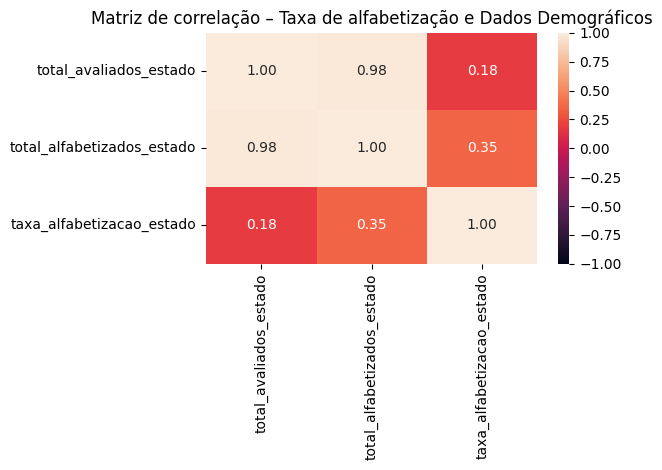

In [137]:
cols_corr = [c for c in ["total_avaliados_estado","total_alfabetizados_estado","taxa_alfabetizacao_estado"] if c in df_evol_estado.columns]

# 1. Trata e converte as colunas para float
for col in cols_corr:
    # Se a coluna estiver como texto/object, substitui vírgula por ponto e converte para float
    if df_evol_estado[col].dtype == 'object':
        df_evol_estado[col] = (
            df_evol_estado[col]
            .astype(str)
            .str.replace(',', '.')
        )
    df_evol_estado[col] = pd.to_numeric(
        df_evol_estado[col],
        errors='coerce'  # Transforma textos inválidos em NaN para evitar erros
    )

# 2. Calcula a correlação
corr = df_evol_estado[cols_corr].corr()

# 3. Plota o gráfico
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – Taxa de alfabetização e Dados Demográficos")
plt.tight_layout()
plt.show()


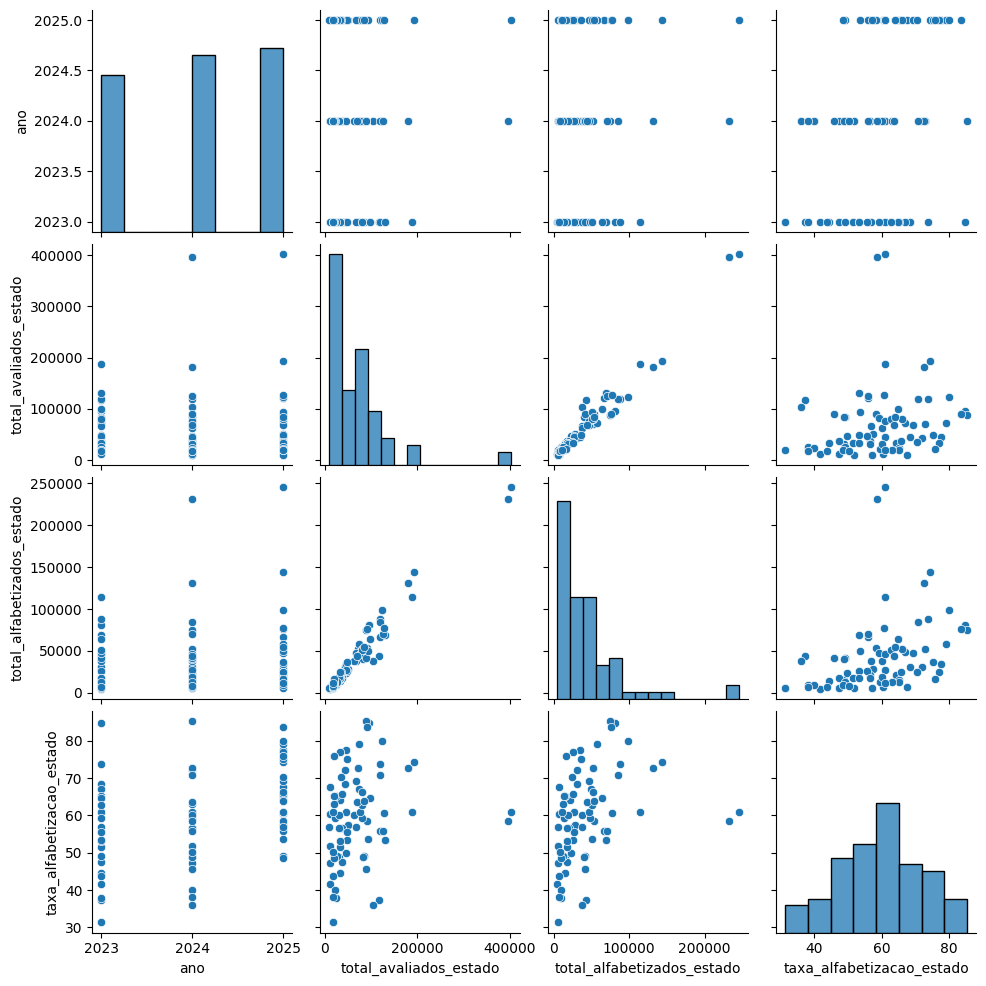

In [136]:
sns.pairplot(df_evol_estado)

Há uma correlação linear positiva entre Total de Avaliados do Estado e Total Alfabetizados (quanto maior o número de avaliados maior o número total de alfabetizados)

**Como não achamos correlações específicas, vamos adicionar o IDHM também para verificar se tem alguma influência na taxa de alfabetização**

In [ ]:
# df_idhm = pd.read_excel('IDH_2010.xls')
# df_idhm.head()


#Baixar csv IDHM
#https://basedosdados.org/dataset/cbfc7253-089b-44e2-8825-755e1419efc8?table=ec5fb3d1-fa98-4ab3-8a02-4b9950048a83

# Meu ID do projeto no GCP
project_id = 'gcpproject-500123'
client = bigquery.Client(project=project_id)

# Query
query = """
    SELECT
    dados.ano AS ano,
    dados.id_municipio AS id_municipio,
    diretorio_id_municipio.nome AS id_municipio_nome,
    dados.idhm AS idhm
FROM `basedosdados.mundo_onu_adh.municipio` AS dados
LEFT JOIN (
    SELECT DISTINCT id_municipio, nome
    FROM `basedosdados.br_bd_diretorios_brasil.municipio`
) AS diretorio_id_municipio
    ON dados.id_municipio = diretorio_id_municipio.id_municipio
WHERE dados.ano = 2010
"""

# Executa e converte para Pandas DataFrame
df_idhm = client.query(query).to_dataframe()

# Exibe as primeiras linhas
df_idhm.head()

## Salvar o DataFrame no ambiente do Colab
#df_censo_raca.to_csv('censo_2022_popul_sexo_raca.csv', index=False)

## Fazer o download para sua máquina
#files.download('censo_2022_popul_sexo_raca.csv')



,ano,id_municipio,id_municipio_nome,idhm
0,2010,1100015,Alta Floresta D'Oeste,0.641
1,2010,1100023,Ariquemes,0.702
2,2010,1100031,Cabixi,0.650
3,2010,1100049,Cacoal,0.718
4,2010,1100056,Cerejeiras,0.692


In [ ]:
##Criando dataset que faz merge entre taxa de alfabetização e IDHM do municipio


# 2. Garante tratamento limpo de texto na chave id_municipio (remove .0 se existir e limpa espaços)
df_indic_alfab_municipio['id_municipio'] = (
    df_indic_alfab_municipio['id_municipio']
    .astype(str)
    .str.strip()
    .str.replace(r'\.0$', '', regex=True)
)

df_idhm['id_municipio'] = (
    df_idhm['id_municipio']
    .astype(str)
    .str.strip()
    .str.replace(r'\.0$', '', regex=True)
)

# 3. Merge com Left Join
df_t_alf_idhm = df_indic_alfab_municipio.merge(
    df_idhm[['id_municipio', 'idhm']],
    on='id_municipio',
    how='left'
)

# 4. Remover colunas extras (apenas se existirem no df)
cols_para_dropar = ['_gold_processed_at', '_analytics_version', 'total_avaliados', 'total_alfabetizados']
df_t_alf_idhm = df_t_alf_idhm.drop(columns=[c for c in cols_para_dropar if c in df_t_alf_idhm.columns])

# 5. Groupby utilizando dropna=False para evitar que NaNs limpem os dados
df_t_alf_idhm = (
    df_t_alf_idhm.groupby(['id_municipio', 'nome_municipio','idhm'], dropna=False)[
        ['taxa_alfabetizacao_real']
    ]
    .mean()
    .round(2)
    .reset_index()
)

df_t_alf_idhm.head()

,id_municipio,nome_municipio,idhm,taxa_alfabetizacao_real
0,1100015,Alta Floresta D'Oeste,0.641,71.18
1,1100023,Ariquemes,0.702,69.36
2,1100031,Cabixi,0.650,77.98
3,1100049,Cacoal,0.718,71.57
4,1100056,Cerejeiras,0.692,71.27


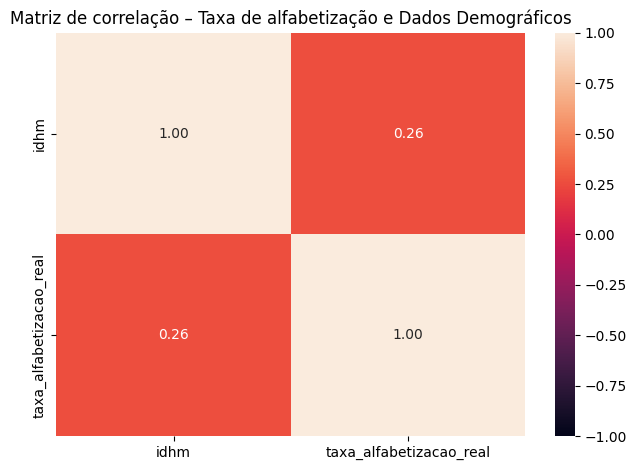

In [135]:
cols_corr = [c for c in ["idhm","taxa_alfabetizacao_real"] if c in df_t_alf_idhm.columns]

# 1. Trata e converte as colunas para float
for col in cols_corr:
    # Se a coluna estiver como texto/object, substitui vírgula por ponto e converte para float
    if df_t_alf_idhm[col].dtype == 'object':
        df_t_alf_idhm[col] = (
            df_t_alf_idhm[col]
            .astype(str)
            .str.replace(',', '.')
        )
    df_t_alf_idhm[col] = pd.to_numeric(
        df_t_alf_idhm[col],
        errors='coerce'  # Transforma textos inválidos em NaN para evitar erros
    )

# 2. Calcula a correlação
corr = df_t_alf_idhm[cols_corr].corr()

# 3. Plota o gráfico
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – Taxa de alfabetização e Dados Demográficos")
plt.tight_layout()
plt.show()


In [ ]:
Sem correlação também entre IDHM e taxa de alfabetização.